#  Children's Drawing Emotion Analysis
### Multimodal Deep Learning with Novel Psychological Feature Extraction

## Setup

In [ ]:
import subprocess, sys
pkgs = [
    "kagglehub", "torch", "torchvision",
    "scikit-learn", "matplotlib", "seaborn",
    "opencv-python-headless", "numpy", "pandas",
    "Pillow", "scikit-image", "tqdm",
    "torchcam", "albumentations", "joblib",
]
for p in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])
print("All packages ready")

All packages ready


In [ ]:
import os, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import joblib
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize, StandardScaler
from skimage.feature import local_binary_pattern
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}  |  PyTorch {torch.__version__}")

Device : cpu  |  PyTorch 2.10.0+cpu


## Download Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("vishmiperera/children-drawings")
print("Dataset path:", path)

Using Colab cache for faster access to the 'children-drawings' dataset.
Dataset path: /kaggle/input/children-drawings


## Load, Clean & Label

In [ ]:
DATA_ROOT  = Path(path)
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

records = []
for p in DATA_ROOT.rglob('*'):
    if p.suffix.lower() in VALID_EXTS:
        records.append({'path': str(p), 'raw_label': p.parent.name})

df = pd.DataFrame(records)
print(f"Total images: {len(df)}")
print(df['raw_label'].value_counts().to_string())

Total images: 1109
raw_label
Sad      287
Fear     283
Angry    272
Happy    267


In [ ]:
def map_label(lbl):
    lbl = lbl.lower().strip()
    if any(k in lbl for k in ['happy','happi','joy','smile']):        return 'happiness'
    if any(k in lbl for k in ['sad','depress','anxiet','fear','worry']): return 'anxiety_depression'
    if any(k in lbl for k in ['ang','aggr','rage','furious']):        return 'anger_aggression'
    return lbl

CLASS_NAMES = ['happiness', 'anxiety_depression', 'anger_aggression']
df['label']     = df['raw_label'].apply(map_label)
df              = df[df['label'].isin(CLASS_NAMES)].copy()
label2idx       = {c: i for i, c in enumerate(CLASS_NAMES)}
idx2label       = {i: c for c, i in label2idx.items()}
NUM_CLASSES     = 3
df['label_idx'] = df['label'].map(label2idx)

print(f"Classes: {CLASS_NAMES}")
print(df['label'].value_counts().to_string())

Classes: ['happiness', 'anxiety_depression', 'anger_aggression']
label
anxiety_depression    570
anger_aggression      272
happiness             267


In [ ]:
def is_valid(p):
    try: Image.open(p).verify(); return True
    except: return False

mask = [is_valid(p) for p in tqdm(df['path'], desc='Validating')]
df   = df[mask].reset_index(drop=True)
print(f"Clean dataset: {len(df)} images  ({sum(1 for m in mask if not m)} removed)")

Validating:   0%|          | 0/1109 [00:00<?, ?it/s]

Clean dataset: 1109 images  (0 removed)


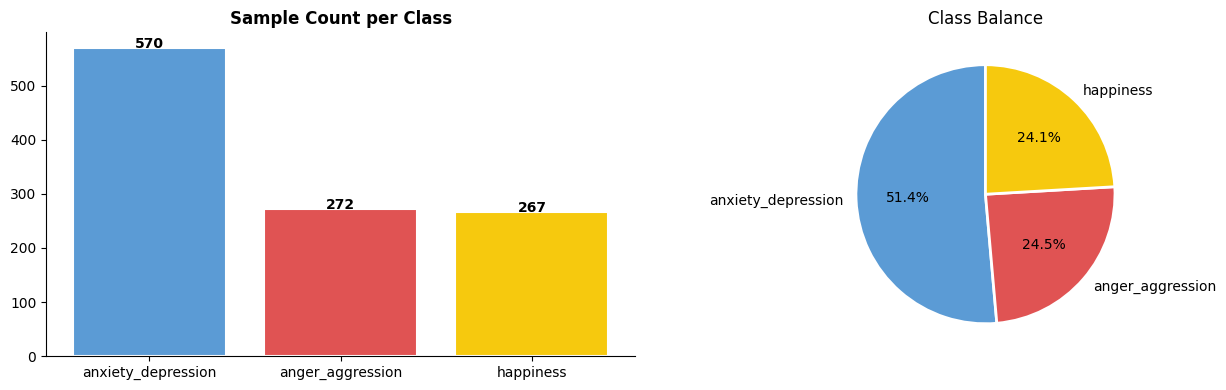

In [ ]:
COLORS = {'happiness':'#F6C90E', 'anxiety_depression':'#5B9BD5', 'anger_aggression':'#E05353'}
counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars = axes[0].bar(counts.index, counts.values,
                   color=[COLORS[c] for c in counts.index], edgecolor='white', lw=1.5)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+.3, str(v), ha='center', fontweight='bold')
axes[0].set_title('Sample Count per Class', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[COLORS[c] for c in counts.index],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Balance')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing Pipeline

In [ ]:
def crop_white_margins(img_bgr, threshold=240):
    gray   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    coords = np.argwhere(gray < threshold)
    if coords.size == 0: return img_bgr
    y0,x0  = coords.min(axis=0)
    y1,x1  = coords.max(axis=0)
    pad    = 5; h,w = img_bgr.shape[:2]
    return img_bgr[max(0,y0-pad):min(h,y1+pad), max(0,x0-pad):min(w,x1+pad)]

def apply_clahe(img_bgr):
    lab      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l,a,b    = cv2.split(lab)
    l_eq     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(l)
    return cv2.cvtColor(cv2.merge([l_eq,a,b]), cv2.COLOR_LAB2BGR)

def preprocess(img_path, size=224):
    img = cv2.imread(img_path)
    if img is None: return np.zeros((size,size,3), dtype=np.uint8)
    img = crop_white_margins(img)
    img = apply_clahe(img)
    img = cv2.resize(img, (size,size))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Preprocessing: white-margin crop → CLAHE → resize 224×224")

Preprocessing: white-margin crop → CLAHE → resize 224×224


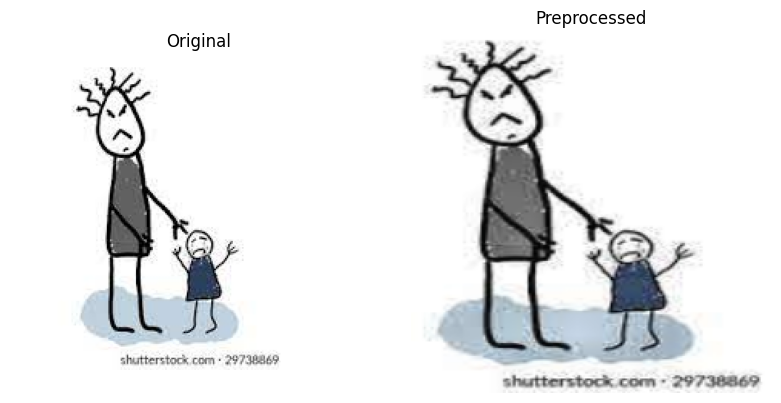

In [ ]:
sample_path = df.sample(1, random_state=SEED)['path'].values[0]
raw   = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
final = preprocess(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(raw);   axes[0].set_title('Original');     axes[0].axis('off')
axes[1].imshow(final); axes[1].set_title('Preprocessed'); axes[1].axis('off')
plt.tight_layout(); plt.savefig('preprocessing_demo.png', dpi=150); plt.show()

## Feature Extraction

We extract **6 feature groups** (total **79 dimensions**):

| # | Feature Group | Dims | Description |
|---|---|---|---|
| 1 | HSV Color Statistics | 15 | Means, variances, warm/cool/dark ratios, hue bins |
| 2 | Compositional/Graphic | 9 | Edge chaos, contour count, fill ratio, symmetry |
| 3 | LBP Texture | 32 | Stroke nervousness via Local Binary Patterns |
| 4 | Spatial Placement | 5 | Figure placement encodes emotion (psychology) |
| 5 | Drawing Complexity | 3 | Agitation score via edge density |
| 6 | **Emotional Gradient Flow**  | 15 | **NEW — directional stroke energy across 5 zones** |

In [ ]:
def feat_hsv(img_rgb):
    hsv   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    H,S,V = hsv[:,:,0]/180., hsv[:,:,1]/255., hsv[:,:,2]/255.
    H_raw = hsv[:,:,0]
    stats = [H.mean(), H.var(), S.mean(), S.var(), V.mean(), V.var()]
    warm  = float(((H_raw<=35)|(H_raw>=155)).mean())
    cool  = float(((H_raw>85)&(H_raw<155)).mean())
    dark  = float((hsv[:,:,2]<60).mean())
    hist,_ = np.histogram(H_raw, bins=6, range=(0,180))
    hbins  = (hist/(hist.sum()+1e-8)).tolist()
    return np.array(stats+[warm,cool,dark]+hbins, dtype=np.float32)  # 15

def feat_composition(img_rgb):
    gray     = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    h,w      = gray.shape
    _,binary = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    M        = cv2.moments(binary)
    cx = (M['m10']/(M['m00']+1e-6))/w if M['m00']>0 else 0.5
    cy = (M['m01']/(M['m00']+1e-6))/h if M['m00']>0 else 0.5
    coords   = np.argwhere(binary>0)
    if len(coords)>0:
        y0,x0=coords.min(axis=0); y1,x1=coords.max(axis=0)
        bbox_ar  = ((y1-y0+1)*(x1-x0+1))/(h*w)
        asp      = (x1-x0+1)/(y1-y0+2)
    else: bbox_ar,asp = 0.,1.
    edges    = cv2.Canny(gray,50,150)
    chaos    = float(edges.astype(np.float32).std()/255.)
    conts,_  = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c_norm   = min(len(conts)/100.,1.)
    fill     = float((binary>0).mean())
    flip     = cv2.flip(binary,1)
    sym      = float((binary.astype(np.float32)*flip.astype(np.float32)).sum()) / \
               float(binary.astype(np.float32).sum()+flip.astype(np.float32).sum()+1e-6)
    sd       = min(float(edges.sum())/(255.*(binary.sum()/255.+1e-6)),1.)
    return np.array([cx,cy,bbox_ar,asp,chaos,c_norm,fill,sym,sd], dtype=np.float32)  # 9

def feat_lbp(img_rgb, radius=3, n_points=24, n_bins=32):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    lbp  = local_binary_pattern(gray, n_points, radius, method='uniform')
    hist,_ = np.histogram(lbp.ravel(), bins=n_bins, range=(0,n_points+2), density=True)
    return hist.astype(np.float32)  # 32

def feat_spatial(img_rgb):
    gray     = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _,binary = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    total    = binary.sum()+1e-6
    h,w      = binary.shape
    top      = binary[:h//2,:].sum()/total
    bot      = binary[h//2:,:].sum()/total
    left     = binary[:,:w//2].sum()/total
    right    = binary[:,w//2:].sum()/total
    M        = cv2.moments(binary)
    cy       = (M['m01']/(M['m00']+1e-6))/h
    return np.array([top,bot,left,right,cy], dtype=np.float32)  # 5

def feat_complexity(img_rgb):
    gray     = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    edges    = cv2.Canny(gray,50,150)
    ed       = edges.sum()/(255.*edges.size)
    _,thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY_INV)
    conts,_  = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return np.array([ed, min(len(conts)/100.,1.), float((thresh>0).mean())], dtype=np.float32)  # 3

print("Feature extractors 1–5 defined")

Feature extractors 1–5 defined


In [ ]:
def feat_emotional_gradient_flow(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    h, w = gray.shape

    # Sobel gradients
    Gx  = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    Gy  = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(Gx**2 + Gy**2)          # gradient magnitude
    ang = np.degrees(np.arctan2(Gy, Gx))  # angle in [-180, 180]

    # Map angles to 3 orientation bins
    abs_ang = np.abs(ang)
    bin_map = np.zeros_like(abs_ang, dtype=np.int32)
    bin_map[abs_ang >= 45]  = 1   # diagonal
    bin_map[abs_ang >= 90]  = 2   # vertical / downward

    # Define 5 zones
    zones = [
        (0,        h//2,  0,        w   ),   # top
        (h//2,     h,     0,        w   ),   # bottom
        (0,        h,     0,        w//2),   # left
        (0,        h,     w//2,     w   ),   # right
        (h//4,  3*h//4,   w//4,  3*w//4),   # centre
    ]

    zone_hists = []
    for (r0,r1,c0,c1) in zones:
        z_mag = mag[r0:r1, c0:c1].ravel()
        z_bin = bin_map[r0:r1, c0:c1].ravel()
        hist  = np.zeros(3, dtype=np.float32)
        for b in range(3):
            hist[b] = z_mag[z_bin == b].sum()
        hist /= (hist.sum() + 1e-8)   # normalise per zone
        zone_hists.extend(hist.tolist())

    return np.array(zone_hists, dtype=np.float32)  # 15-dim

print("Feature 6: Emotional Gradient Flow defined (15-dim)")
print("Encodes directional stroke energy across 5 spatial zones")
print("Total feature vector: 15+9+32+5+3+15 = 79 dims")

Feature 6: Emotional Gradient Flow defined (15-dim)
Encodes directional stroke energy across 5 spatial zones
Total feature vector: 15+9+32+5+3+15 = 79 dims


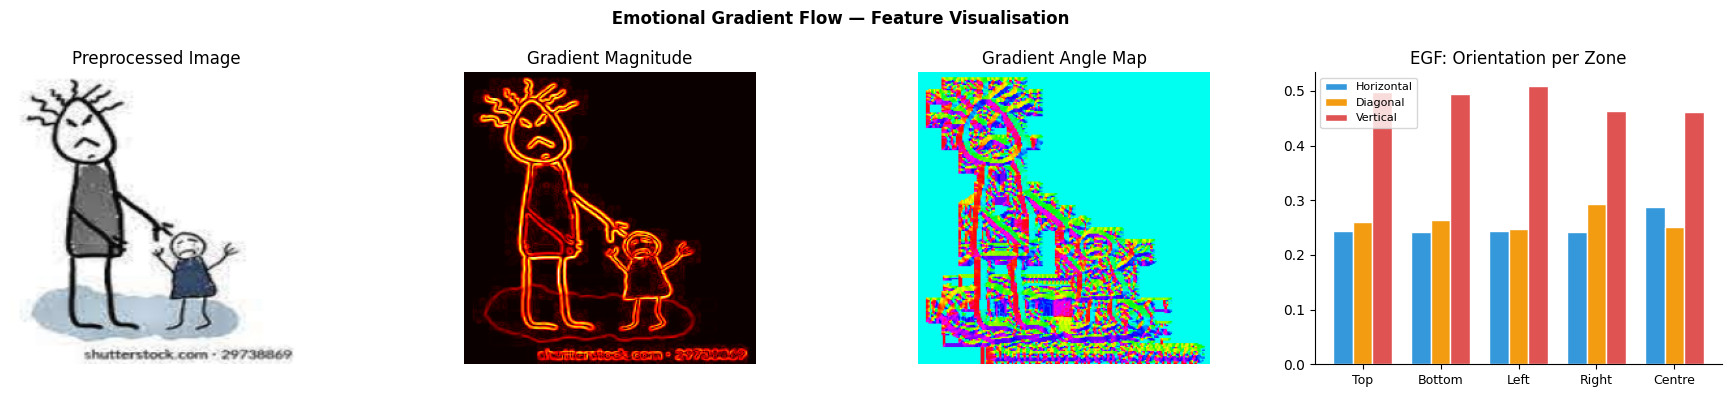

In [ ]:
sample_rgb = preprocess(sample_path)
gray_s     = cv2.cvtColor(sample_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
Gx = cv2.Sobel(gray_s, cv2.CV_32F, 1, 0, ksize=3)
Gy = cv2.Sobel(gray_s, cv2.CV_32F, 0, 1, ksize=3)
mag_vis  = np.sqrt(Gx**2 + Gy**2)
ang_vis  = np.degrees(np.arctan2(Gy, Gx))
egf_vec  = feat_emotional_gradient_flow(sample_rgb)
zone_labels = ['Top','Bottom','Left','Right','Centre']
bin_labels  = ['Horizontal','Diagonal','Vertical']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(' Emotional Gradient Flow — Feature Visualisation', fontweight='bold')

axes[0].imshow(sample_rgb);       axes[0].set_title('Preprocessed Image'); axes[0].axis('off')
axes[1].imshow(mag_vis, cmap='hot'); axes[1].set_title('Gradient Magnitude'); axes[1].axis('off')
axes[2].imshow(ang_vis, cmap='hsv'); axes[2].set_title('Gradient Angle Map'); axes[2].axis('off')

# Bar chart: 5 zones × 3 bins
x     = np.arange(len(zone_labels))
width = 0.25
bar_colors = ['#3498DB','#F39C12','#E05353']
for i, (bl,bc) in enumerate(zip(bin_labels, bar_colors)):
    vals = [egf_vec[z*3+i] for z in range(5)]
    axes[3].bar(x + i*width, vals, width, label=bl, color=bc, edgecolor='white')
axes[3].set_xticks(x+width); axes[3].set_xticklabels(zone_labels, fontsize=9)
axes[3].set_title('EGF: Orientation per Zone'); axes[3].legend(fontsize=8)
axes[3].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('egf_feature_demo.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def extract_all(img_rgb):
    return np.concatenate([
        feat_hsv(img_rgb),                      # 15
        feat_composition(img_rgb),              #  9
        feat_lbp(img_rgb),                      # 32
        feat_spatial(img_rgb),                  #  5
        feat_complexity(img_rgb),               #  3
        feat_emotional_gradient_flow(img_rgb),  # 15
    ]).astype(np.float32)  # 79-dim total

print("extract_all() → 79-dim vector")

extract_all() → 79-dim vector


## Feature Caching

In [ ]:
CACHE_FILE = 'features_cache.npz'

if os.path.exists(CACHE_FILE):
    print("Loading cached features...")
    cache        = np.load(CACHE_FILE, allow_pickle=True)
    all_feats    = cache['feats']
    cached_paths = cache['paths'].tolist()
    path_to_i    = {p: i for i, p in enumerate(cached_paths)}
    df           = df[df['path'].isin(set(cached_paths))].reset_index(drop=True)
    all_feats    = all_feats[[path_to_i[p] for p in df['path']]]
    print(f" Loaded {len(df)} vectors  shape={all_feats.shape}")
else:
    print("Extracting features (cached after first run)...")
    feat_list, valid_paths, valid_idx = [], [], []
    for i, row in tqdm(df.iterrows(), total=len(df), desc='Extracting'):
        try:
            img = preprocess(row['path'])
            feat_list.append(extract_all(img))
            valid_paths.append(row['path'])
            valid_idx.append(i)
        except: pass

    df        = df.loc[valid_idx].reset_index(drop=True)
    all_feats = np.stack(feat_list).astype(np.float32)
    np.savez(CACHE_FILE, feats=all_feats, paths=np.array(valid_paths))
    print(f" Saved to '{CACHE_FILE}'  shape={all_feats.shape}")

Extracting features (cached after first run)...


Extracting:   0%|          | 0/1109 [00:00<?, ?it/s]

 Saved to 'features_cache.npz'  shape=(1109, 79)


## Split & Normalise

In [ ]:
df['feat_idx'] = range(len(df))

train_df, temp_df = train_test_split(df, test_size=0.30,
                                      stratify=df['label_idx'], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                      stratify=temp_df['label_idx'], random_state=SEED)

tr_i, va_i, te_i = (train_df['feat_idx'].values,
                    val_df['feat_idx'].values,
                    test_df['feat_idx'].values)

scaler   = StandardScaler()
f_train  = scaler.fit_transform(all_feats[tr_i])
f_val    = scaler.transform(all_feats[va_i])
f_test   = scaler.transform(all_feats[te_i])
joblib.dump(scaler, 'feature_scaler.pkl')

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(f"Feature vector: {f_train.shape[1]}-dim (z-score normalised)")

Train: 776  Val: 166  Test: 167
Feature vector: 79-dim (z-score normalised)


## Augmentation & Dataset

In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.CoarseDropout(max_holes=1, max_height=16, max_width=16, fill_value=0, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

class DrawingDataset(Dataset):
    def __init__(self, dataframe, features, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.features  = features.astype(np.float32)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = preprocess(row['path'])
        label = int(row['label_idx'])
        if self.transform:
            img = self.transform(image=img)['image']
        else:
            img = torch.from_numpy(img.transpose(2,0,1)).float()/255.
        return img, torch.from_numpy(self.features[idx]), label

train_ds = DrawingDataset(train_df, f_train, train_aug)
val_ds   = DrawingDataset(val_df,   f_val,   val_aug)
test_ds  = DrawingDataset(test_df,  f_test,  val_aug)

class_counts  = train_df['label_idx'].value_counts().sort_index().values
class_weights = 1.0 / np.sqrt(class_counts.astype(np.float32))
sample_w      = class_weights[train_df['label_idx'].values]
sampler       = WeightedRandomSampler(torch.from_numpy(sample_w), len(sample_w), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

print(f" Dataloaders ready  train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}")

 Dataloaders ready  train=25 val=6 test=6


## Model Architecture

```
Input image
    │
    ├─► EfficientNet-B3 ──────────────────────────► 1536-dim
    │
    └─► Hand-crafted features (79-dim)
              │
              ▼
       Attention Fusion Layer → 256-dim
              │
              ▼
       MLP: 256 → 128 → ReLU → Dropout(0.5) → 3
              │
              ▼
       Softmax → {Happiness, Anxiety/Depression, Anger/Aggression}
```

In [ ]:
FEAT_DIM   = f_train.shape[1]   # 79
FUSION_DIM = 256

class AttentionFusion(nn.Module):
    def __init__(self, channel_dims, fusion_dim=256):
        super().__init__()
        self.projectors = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d, fusion_dim),
                nn.BatchNorm1d(fusion_dim),
                nn.ReLU(),
            ) for d in channel_dims
        ])
        self.attention = nn.Sequential(
            nn.Linear(fusion_dim * len(channel_dims), len(channel_dims)),
            nn.Softmax(dim=1)
        )

    def forward(self, *inputs):
        projected = [p(x) for p, x in zip(self.projectors, inputs)]
        alpha     = self.attention(torch.cat(projected, dim=1)).unsqueeze(-1)
        return (alpha * torch.stack(projected, dim=1)).sum(dim=1)

class EmotionModel(nn.Module):
    def __init__(self, num_classes=3, feat_dim=FEAT_DIM, fusion_dim=FUSION_DIM):
        super().__init__()
        backbone = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        for i, child in enumerate(backbone.features.children()):
            if i < 5:
                for p in child.parameters(): p.requires_grad = False
        self.cnn_dim  = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.backbone = backbone
        self.fusion   = AttentionFusion([self.cnn_dim, feat_dim], fusion_dim)
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, feats):
        return self.classifier(self.fusion(self.backbone(img), feats))

model   = EmotionModel(NUM_CLASSES).to(DEVICE)
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"EfficientNet-B3 + Attention Fusion (256-dim)")
print(f"Total: {total:,}  |  Trainable: {trainable:,} ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 107MB/s]


EfficientNet-B3 + Attention Fusion (256-dim)
Total: 11,145,517  |  Trainable: 10,343,123 (92.8%)


## Training

In [ ]:
NUM_EPOCHS   = 40
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 10
MIXUP_ALPHA  = 0.2

cw_tensor = torch.tensor(class_weights/class_weights.sum(), dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.05)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def mixup(imgs, feats, labels, alpha=0.2):
    lam  = np.random.beta(alpha, alpha) if alpha > 0 else 1.
    idx  = torch.randperm(imgs.size(0))
    return (lam*imgs + (1-lam)*imgs[idx],
            lam*feats + (1-lam)*feats[idx],
            labels, labels[idx], lam)

def mixup_loss(criterion, pred, ya, yb, lam):
    return lam*criterion(pred,ya) + (1-lam)*criterion(pred,yb)

history     = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
best_val    = 0.0
pat_count   = 0
BEST_PATH   = 'best_model.pth'

print(f"{'Ep':>4} {'TrLoss':>8} {'TrAcc':>8} {'VaLoss':>8} {'VaAcc':>8}")
print('─'*46)

for epoch in range(1, NUM_EPOCHS+1):

    model.train()
    tl,tc,tt = 0.,0,0
    for imgs, feats, labels in train_loader:
        imgs,feats,labels = imgs.to(DEVICE),feats.to(DEVICE),labels.to(DEVICE)
        imgs,feats,ya,yb,lam = mixup(imgs,feats,labels,MIXUP_ALPHA)
        optimizer.zero_grad()
        out  = model(imgs,feats)
        loss = mixup_loss(criterion,out,ya,yb,lam)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        tl += loss.item()*imgs.size(0)
        dom = ya if lam>=0.5 else yb
        tc += (out.argmax(1)==dom).sum().item(); tt += labels.size(0)

    model.eval()
    vl,vc,vt = 0.,0,0
    with torch.no_grad():
        for imgs,feats,labels in val_loader:
            imgs,feats,labels = imgs.to(DEVICE),feats.to(DEVICE),labels.to(DEVICE)
            out  = model(imgs,feats)
            loss = criterion(out,labels)
            vl += loss.item()*imgs.size(0)
            vc += (out.argmax(1)==labels).sum().item(); vt += labels.size(0)

    scheduler.step()
    ta,va = tc/tt, vc/vt
    history['train_loss'].append(tl/tt); history['train_acc'].append(ta)
    history['val_loss'].append(vl/vt);   history['val_acc'].append(va)

    flag = ''
    if va > best_val:
        best_val = va; torch.save(model.state_dict(),BEST_PATH)
        pat_count = 0; flag = ''
    else:
        pat_count += 1

    print(f"{epoch:>4} {tl/tt:>8.4f} {ta:>8.3%} {vl/vt:>8.4f} {va:>8.3%}{flag}")
    if pat_count >= PATIENCE:
        print(f"\n  Early stopping at epoch {epoch}"); break

print(f"\n Best val accuracy: {best_val:.3%}")

  Ep   TrLoss    TrAcc   VaLoss    VaAcc
──────────────────────────────────────────────
   1   1.0698  39.433%   1.0729  43.373%
   2   0.9605  55.155%   0.9080  60.843%
   3   0.8143  67.784%   0.7717  72.892%
   4   0.7166  76.804%   0.6920  77.711%
   5   0.6839  78.995%   0.6509  79.518%
   6   0.6861  80.412%   0.6397  81.928%
   7   0.6087  82.861%   0.6458  80.723%
   8   0.5675  87.113%   0.6342  78.916%
   9   0.4539  88.918%   0.6183  80.723%
  10   0.5145  90.077%   0.6403  79.518%
  11   0.5077  90.077%   0.6372  80.723%
  12   0.5337  90.077%   0.6465  80.723%
  13   0.4436  93.557%   0.6516  81.325%
  14   0.4505  92.655%   0.6807  80.120%
  15   0.4997  92.397%   0.6658  81.325%


In [ ]:
ep = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].plot(ep, history['train_acc'], label='Train', color='#3498DB', lw=2)
axes[0].plot(ep, history['val_acc'],   label='Val',   color='#E74C3C', lw=2)
axes[0].axhline(best_val, ls='--', color='#2ECC71', lw=1.5, label=f'Best {best_val:.1%}')
axes[0].set_title('Accuracy', fontweight='bold'); axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(ep, history['train_loss'], label='Train', color='#3498DB', lw=2)
axes[1].plot(ep, history['val_loss'],   label='Val',   color='#E74C3C', lw=2)
axes[1].set_title('Loss', fontweight='bold'); axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation

In [ ]:
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [],[],[]
with torch.no_grad():
    for imgs,feats,labels in tqdm(test_loader, desc='Testing'):
        out   = model(imgs.to(DEVICE), feats.to(DEVICE))
        all_probs.extend(torch.softmax(out,1).cpu().numpy())
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
test_acc   = (all_preds==all_labels).mean()

print(f"\n{'='*50}")
print(f"  TEST ACCURACY : {test_acc:.4%}")
print(f"{'='*50}\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

In [ ]:
SHORT  = ['Happy','Anx/Dep','Anger']
cm     = confusion_matrix(all_labels, all_preds)
cm_n   = cm.astype(float)/cm.sum(axis=1,keepdims=True)

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Confusion Matrix — Test Set', fontweight='bold')
for ax,data,fmt,title in zip(axes,[cm,cm_n],['d','.2%'],['Absolute','Row-Normalised']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=SHORT, yticklabels=SHORT, linewidths=0.5)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
labels_bin = label_binarize(all_labels, classes=[0,1,2])
fig, ax    = plt.subplots(figsize=(7,6))
auc_scores = []
for i,(cls,col) in enumerate(zip(CLASS_NAMES,['#F6C90E','#5B9BD5','#E05353'])):
    fpr,tpr,_ = roc_curve(labels_bin[:,i], all_probs[:,i])
    v = auc(fpr,tpr); auc_scores.append(v)
    ax.plot(fpr,tpr,lw=2,color=col,label=f'{cls} (AUC={v:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_title(f'ROC Curves | Macro-AUC={np.mean(auc_scores):.3f}', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(loc='lower right'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Grad-CAM Explainability

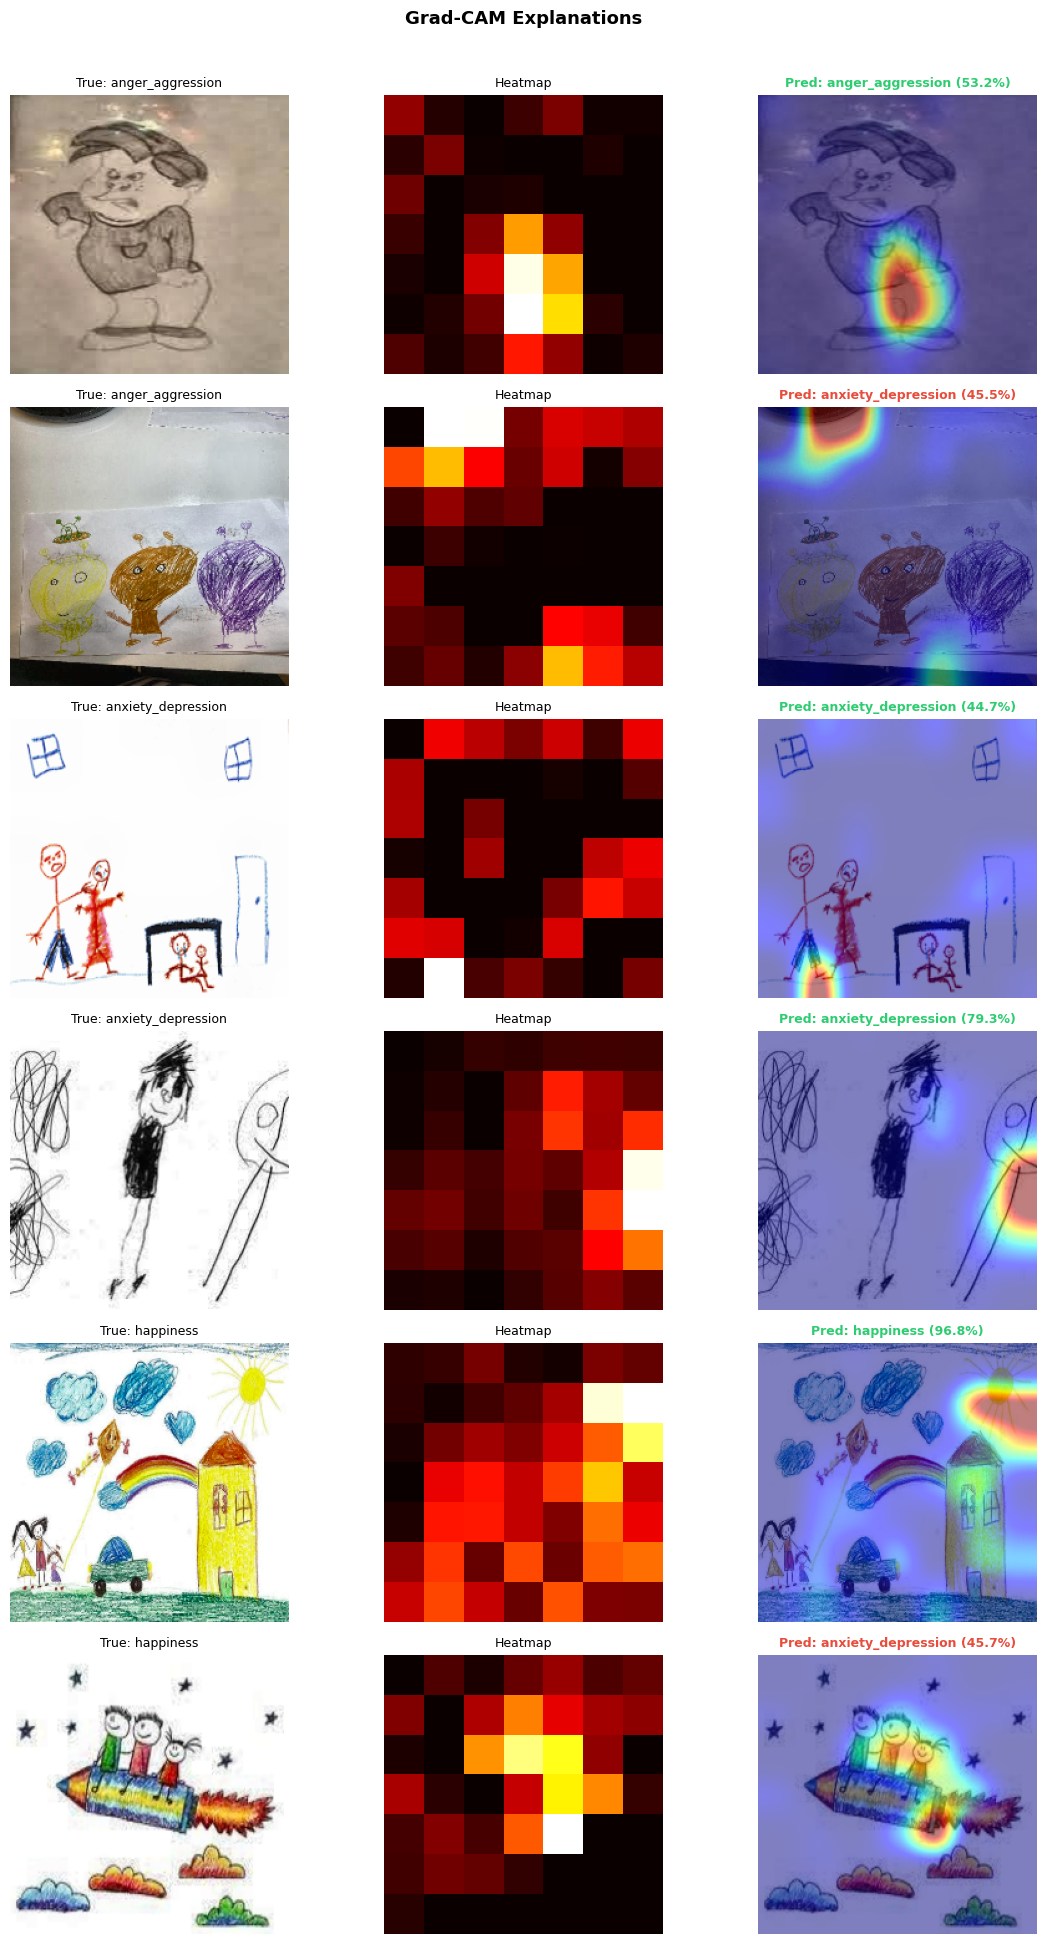

In [ ]:
cam   = GradCAM(model.backbone, target_layer='features.8')
model.eval()

samples = test_df.groupby('label').apply(
    lambda g: g.sample(min(2,len(g)), random_state=SEED)).reset_index(drop=True)

fig, axes = plt.subplots(len(samples),3, figsize=(12,len(samples)*3.2))
if len(samples)==1: axes=axes[np.newaxis,:]
fig.suptitle('Grad-CAM Explanations', fontsize=13, fontweight='bold', y=1.01)

for ri,(_,srow) in enumerate(samples.iterrows()):
    img_rgb = preprocess(srow['path'])
    img_t   = val_aug(image=img_rgb)['image'].unsqueeze(0).to(DEVICE)
    si      = list(test_df.index).index(srow.name) if srow.name in test_df.index else 0
    ft      = torch.from_numpy(f_test[si]).unsqueeze(0).to(DEVICE)

    out     = model(img_t,ft)
    pred    = out.argmax(1).item()
    conf    = torch.softmax(out,1)[0,pred].item()
    act     = cam(pred,out)
    overlay = overlay_mask(Image.fromarray(img_rgb),
                            Image.fromarray(act[0].squeeze().numpy()), alpha=0.5)

    axes[ri,0].imshow(img_rgb)
    axes[ri,0].set_title(f'True: {srow["label"]}', fontsize=9); axes[ri,0].axis('off')
    axes[ri,1].imshow(act[0].squeeze(), cmap='hot')
    axes[ri,1].set_title('Heatmap', fontsize=9); axes[ri,1].axis('off')
    c = '#2ECC71' if pred==srow['label_idx'] else '#E74C3C'
    axes[ri,2].imshow(overlay)
    axes[ri,2].set_title(f'Pred: {CLASS_NAMES[pred]} ({conf:.1%})',
                          color=c, fontsize=9, fontweight='bold')
    axes[ri,2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
cam.remove_hooks()

## Save All Outputs

In [ ]:
rpt  = classification_report(all_labels, all_preds,
                              target_names=CLASS_NAMES, output_dict=True)
mf1  = rpt['macro avg']['f1-score']
mauc = np.mean(auc_scores)

with open('label_mapping.json','w') as f:
    json.dump({'label2idx':label2idx,'idx2label':idx2label,
               'class_names':CLASS_NAMES,'num_classes':NUM_CLASSES}, f, indent=2)

pd.DataFrame(history).to_csv('training_history.csv', index=False)

pred_df = test_df.copy()
pred_df['predicted']  = [CLASS_NAMES[i] for i in all_preds]
pred_df['correct']    = (all_preds==all_labels)
pred_df['confidence'] = all_probs.max(axis=1)
for i,c in enumerate(CLASS_NAMES):
    pred_df[f'prob_{c}'] = all_probs[:,i]
pred_df.to_csv('test_predictions.csv', index=False)

print("Saved: best_model.pth, feature_scaler.pkl, label_mapping.json")
print("training_history.csv, test_predictions.csv, features_cache.npz")
print(f"""
╗
         FINAL RESULTS SUMMARY

  Test Accuracy : {test_acc:.2%}
  Macro F1      : {mf1:.4f}
  Macro AUC     : {mauc:.4f}
╝
""")

Saved: best_model.pth, feature_scaler.pkl, label_mapping.json
training_history.csv, test_predictions.csv, features_cache.npz

╗
         FINAL RESULTS SUMMARY           

  Test Accuracy : 81.44%                 
  Macro F1      : 0.8089                  
  Macro AUC     : 0.9019                  
╝



In [ ]:
from google.colab import files

files.download('best_model.pth')
files.download('label_mapping.json')
files.download('feature_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>